# Feature Analysis: Welch PSD and Autocorrelation by Species

This notebook produces publication-ready plots:
1. Welch PSD by species (median with IQR band)
2. Autocorrelation by species (median with IQR band)
3. Mean autocorrelation at selected lags by species

All plots saved as PDF in `data/processed/feature_latex_figures/`

In [1]:
# Imports
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import butter, filtfilt, welch
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [2]:
# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_AUDIO_DIR = DATA_DIR / "interim" / "consolidated"
SUMMARY_CSV = DATA_DIR / "interim" / "consolidated_summary.csv"
OUTPUT_DIR = PROJECT_ROOT / "results" /"latex_figures" / "feature_latex_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Audio directory: {RAW_AUDIO_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /home/ubuntu-wsl/Projects/Dottorato/001_footsteps_rf
Audio directory: /home/ubuntu-wsl/Projects/Dottorato/001_footsteps_rf/data/interim/consolidated
Output directory: /home/ubuntu-wsl/Projects/Dottorato/001_footsteps_rf/results/latex_figures/feature_latex_figures


In [3]:
# Constants
SAMPLE_RATE = 800  # Hz
LOWPASS_CUTOFF = 250.0  # Hz
LOWPASS_ORDER = 4

# PSD parameters
NPERSEG = 256
DF = SAMPLE_RATE / NPERSEG  # 3.125 Hz per bin
FREQ_MAX = 250  # Hz
EPS = 1e-12
HIGHLIGHT_BINS = [5, 8]  # Welch PSD coefficients

# Autocorrelation parameters
FS = 800
TS_MS = 1000.0 / FS  # 1.25 ms
MAX_LAG = 40  # up to 50 ms
HIGHLIGHT_LAGS = [1, 2, 3, 4, 6, 7, 9]

# Class definitions
CLASS_NAMES = {
    'BB': 'Black Bear',
    'C': 'Cougar',
    'GW': 'Grey Wolf',
    'WTD': 'White-tailed Deer'
}

CLASS_COLORS = {
    'BB': '#1f77b4',   # Blue
    'C': '#ff7f0e',    # Orange
    'GW': '#2ca02c',   # Green
    'WTD': '#d62728'   # Red
}

In [4]:
# Helper functions
def apply_lowpass_filter(signal, cutoff, fs, order):
    """Apply Butterworth lowpass filter."""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

def compute_autocorrelation(signal, max_lag):
    """Compute normalized autocorrelation."""
    n = len(signal)
    signal = signal - np.mean(signal)
    autocorr = np.correlate(signal, signal, mode='full')
    autocorr = autocorr[n-1:n+max_lag]  # Take positive lags
    autocorr = autocorr / autocorr[0]  # Normalize
    return autocorr

In [5]:
# Load metadata
metadata_df = pd.read_csv(SUMMARY_CSV)
print(f"Metadata shape: {metadata_df.shape}")
print(f"\nSamples per class:")
print(metadata_df['category'].value_counts().sort_index())

# Get all files per category
all_files = {}
for category in CLASS_NAMES.keys():
    class_files = metadata_df[metadata_df['category'] == category]['filename'].tolist()
    all_files[category] = class_files

for cat, files in all_files.items():
    print(f"{cat}: {len(files)} files")

Metadata shape: (1686, 5)

Samples per class:
category
BB     477
C      315
GW     651
WTD    243
Name: count, dtype: int64
BB: 477 files
C: 315 files
GW: 651 files
WTD: 243 files


In [6]:
# Load ALL signals for each class
print("Loading ALL audio signals...\n")
signals_all = {}
for category, files in all_files.items():
    class_signals = []
    for fname in files:
        audio_path = RAW_AUDIO_DIR / fname
        if audio_path.exists():
            signal, sr = sf.read(audio_path)
            # Convert to mono if stereo
            if signal.ndim > 1:
                signal = signal.mean(axis=1)
            # Apply lowpass filter
            signal = apply_lowpass_filter(signal, LOWPASS_CUTOFF, sr, LOWPASS_ORDER)
            class_signals.append(signal)
    signals_all[category] = class_signals
    print(f"{category}: Loaded {len(class_signals)} signals")

total_signals = sum(len(s) for s in signals_all.values())
print(f"\nTotal signals loaded: {total_signals}")

Loading ALL audio signals...

BB: Loaded 477 signals
C: Loaded 315 signals
GW: Loaded 651 signals
WTD: Loaded 243 signals

Total signals loaded: 1686


In [7]:
# Compute Welch PSD for ALL samples
print("Computing Welch Power Spectral Density...\n")

psd_data = {}
for category, class_signals in signals_all.items():
    psd_array = []
    for signal in class_signals:
        freqs, psd = welch(signal, fs=SAMPLE_RATE, nperseg=min(256, len(signal)))
        psd_array.append(psd)
    psd_data[category] = {
        'freqs': freqs,
        'psd_array': np.array(psd_array),
        'mean': np.mean(psd_array, axis=0),
        'std': np.std(psd_array, axis=0)
    }
    print(f"{category}: {len(class_signals)} samples, {len(freqs)} frequency bins")

print(f"\nPSD computation complete.")

Computing Welch Power Spectral Density...

BB: 477 samples, 129 frequency bins
C: 315 samples, 129 frequency bins
GW: 651 samples, 129 frequency bins
WTD: 243 samples, 129 frequency bins

PSD computation complete.


In [8]:
# Compute Autocorrelation for ALL samples
print("Computing Autocorrelation...\n")

autocorr_data = {}
for category, class_signals in signals_all.items():
    autocorr_array = []
    for signal in class_signals:
        autocorr = compute_autocorrelation(signal, MAX_LAG)
        autocorr_array.append(autocorr)
    autocorr_data[category] = {
        'autocorr_array': np.array(autocorr_array),
        'mean': np.mean(autocorr_array, axis=0),
        'std': np.std(autocorr_array, axis=0)
    }
    print(f"{category}: {len(class_signals)} samples")

print(f"\nAutocorrelation computation complete.")

Computing Autocorrelation...

BB: 477 samples
C: 315 samples
GW: 651 samples
WTD: 243 samples

Autocorrelation computation complete.


Saved: /home/ubuntu-wsl/Projects/Dottorato/001_footsteps_rf/results/latex_figures/feature_latex_figures/welch_psd_by_species.pdf


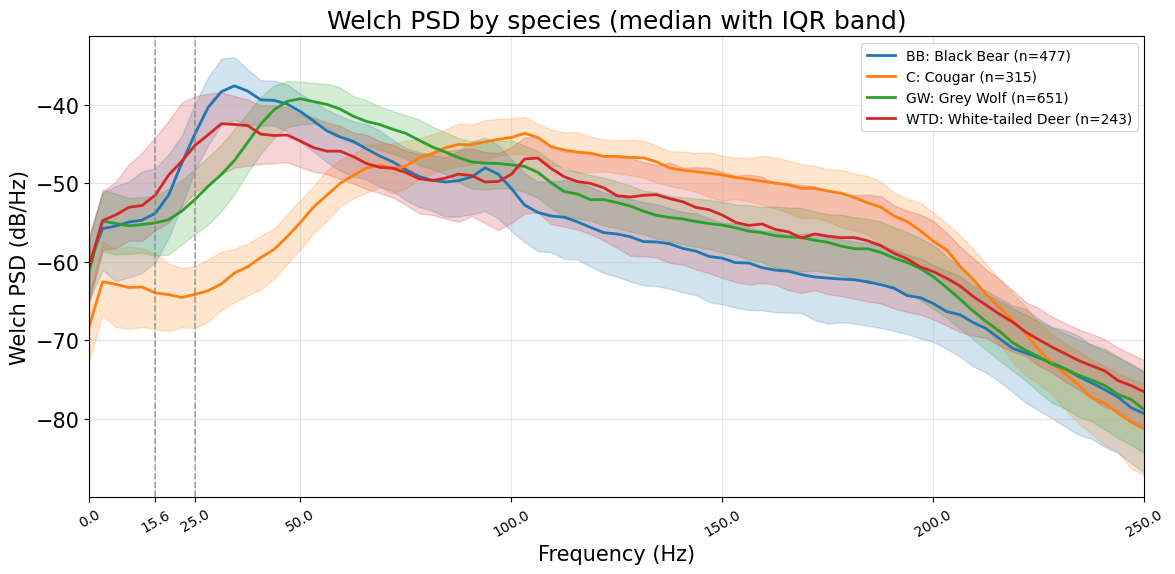

In [15]:
# Plot 1: Welch PSD by species (median with IQR band)
fig, ax = plt.subplots(figsize=(12, 6))

# Get canonical frequency grid
_any_code = next(iter(psd_data.keys()))
freqs_all = np.asarray(psd_data[_any_code]["freqs"])
mask = freqs_all <= FREQ_MAX
freqs_plot = freqs_all[mask]

for code, name in CLASS_NAMES.items():
    if code not in psd_data:
        continue

    psd_arr = np.asarray(psd_data[code]["psd_array"])  # (n_samples, n_freqs)
    n_samples = psd_arr.shape[0]

    # Restrict band and convert to dB
    psd_band = psd_arr[:, mask]
    psd_db = 10.0 * np.log10(np.maximum(psd_band, EPS))

    # Median + IQR
    med = np.median(psd_db, axis=0)
    q25 = np.percentile(psd_db, 25, axis=0)
    q75 = np.percentile(psd_db, 75, axis=0)

    ax.fill_between(freqs_plot, q25, q75, alpha=0.20, color=CLASS_COLORS[code])
    ax.plot(freqs_plot, med, linewidth=2,
            label=f"{code}: {name} (n={n_samples})",
            #label=f"{code}: {name}",
            color=CLASS_COLORS[code])

# Highlight bins with vertical lines
highlight_freqs = []
for b in HIGHLIGHT_BINS:
    if b < len(freqs_all):
        f0 = freqs_all[b]
        if f0 <= FREQ_MAX:
            highlight_freqs.append(float(f0))
            ax.axvline(f0, color="gray", linestyle="--", alpha=0.7, linewidth=1.2)

# Add highlighted frequencies to ticks
base_ticks = list(ax.get_xticks())
for f0 in highlight_freqs:
    base_ticks.append(f0)
ticks = sorted(set([t for t in base_ticks if 0 <= t <= FREQ_MAX]))
ax.set_xticks(ticks)

ax.set_xlim(0, FREQ_MAX)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Welch PSD (dB/Hz)")
ax.set_title("Welch PSD by species (median with IQR band)")
#ax.set_title("Welch PSD by species")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=10)
plt.setp(ax.get_xticklabels(), rotation=30, fontsize=10)

plt.tight_layout()
plt.rcParams.update({'font.size': 15})
pdf_path = OUTPUT_DIR / 'welch_psd_by_species.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")
plt.show()

Saved: /home/ubuntu-wsl/Projects/Dottorato/001_footsteps_rf/results/latex_figures/feature_latex_figures/autocorrelation_by_species.pdf


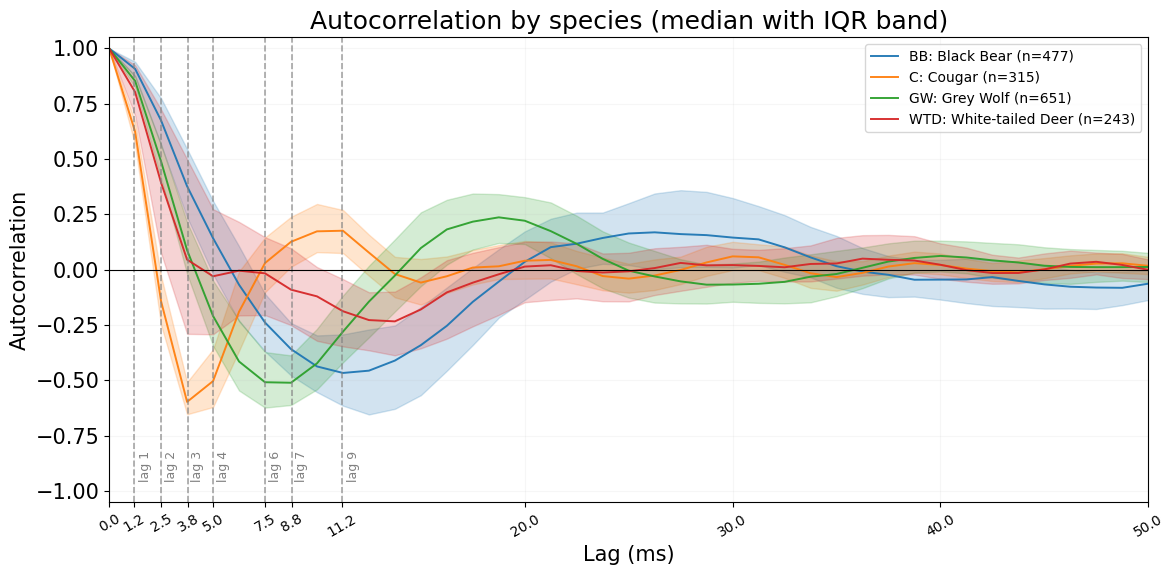

In [14]:
# Plot 2: Autocorrelation by species (median with IQR band)
lags = np.arange(MAX_LAG + 1)
lags_ms = lags * TS_MS

fig, ax = plt.subplots(figsize=(12, 6))

for code, name in CLASS_NAMES.items():
    if code not in autocorr_data:
        continue

    acf_arr = np.asarray(autocorr_data[code]["autocorr_array"])  # (n_samples, n_lags)
    n_samples = acf_arr.shape[0]

    acf_band = acf_arr[:, :MAX_LAG + 1]

    med = np.median(acf_band, axis=0)
    q25 = np.percentile(acf_band, 25, axis=0)
    q75 = np.percentile(acf_band, 75, axis=0)

    ax.fill_between(lags_ms, q25, q75, alpha=0.20, color=CLASS_COLORS[code])
    # Median as a subtle continuous line
    ax.plot(lags_ms, med, linewidth=1.4, linestyle='-',
            label=f"{code}: {name} (n={n_samples})",
            color=CLASS_COLORS[code],
            alpha=0.95)
    # Small markers at each lag to show the median points (subtle)
    #ax.scatter(lags_ms, med, s=20, marker='o',
    #           color=CLASS_COLORS[code], edgecolors='none',
    #           alpha=0.9)

# Highlight lags (gray bands)
highlight_ms = []
for lag in HIGHLIGHT_LAGS:
    if 0 <= lag <= MAX_LAG:
        x0 = round(lag * TS_MS, 1)
        highlight_ms.append(float(x0))
        #ax.axvspan(x0 - 0.01 * TS_MS, x0 + 0.01 * TS_MS, alpha=0.90, color="gray")
        ax.axvline(x0, color="gray", linestyle="--", alpha=0.7, linewidth=1.2)

# Add highlighted lag positions to ticks
base_ticks = list(ax.get_xticks())
for x0 in highlight_ms:
    base_ticks.append(x0)
ticks = sorted(set(round(float(t), 1) for t in base_ticks if 0 <= float(t) <= MAX_LAG * TS_MS))
# Remove tick at 10 ms
ticks = [t for t in ticks if not np.isclose(t, 10.0)]

ax.set_xticks(ticks)
ax.set_xticklabels([f"{t:.1f}" for t in ticks])

# Annotate lag indices
y_top = -0.99
for i, lag in enumerate(HIGHLIGHT_LAGS):
    if 0 <= lag <= MAX_LAG:
        x0 = lag * TS_MS + 0.2
        dy = 5
        va = 'top' if dy < 0 else 'bottom'
        ax.annotate(
            f"lag {lag}",
            xy=(x0, y_top),
            xytext=(0, dy),
            textcoords="offset points",
            ha="left",
            va=va,
            fontsize=9,
            color="gray",
            rotation=90
        )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlim(0, MAX_LAG * TS_MS)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Autocorrelation by species (median with IQR band)")
#ax.set_title("Autocorrelation by species")
ax.grid(True, alpha=0.1)
ax.legend(loc="upper right", fontsize=10)
plt.setp(ax.get_xticklabels(), rotation=30, fontsize=10)

plt.tight_layout()
plt.rcParams.update({'font.size': 15})
pdf_path = OUTPUT_DIR / 'autocorrelation_by_species.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")
plt.show()

Saved: /home/ubuntu-wsl/Projects/Dottorato/001_footsteps_rf/results/latex_figures/feature_latex_figures/mean_autocorr_selected_lags.pdf


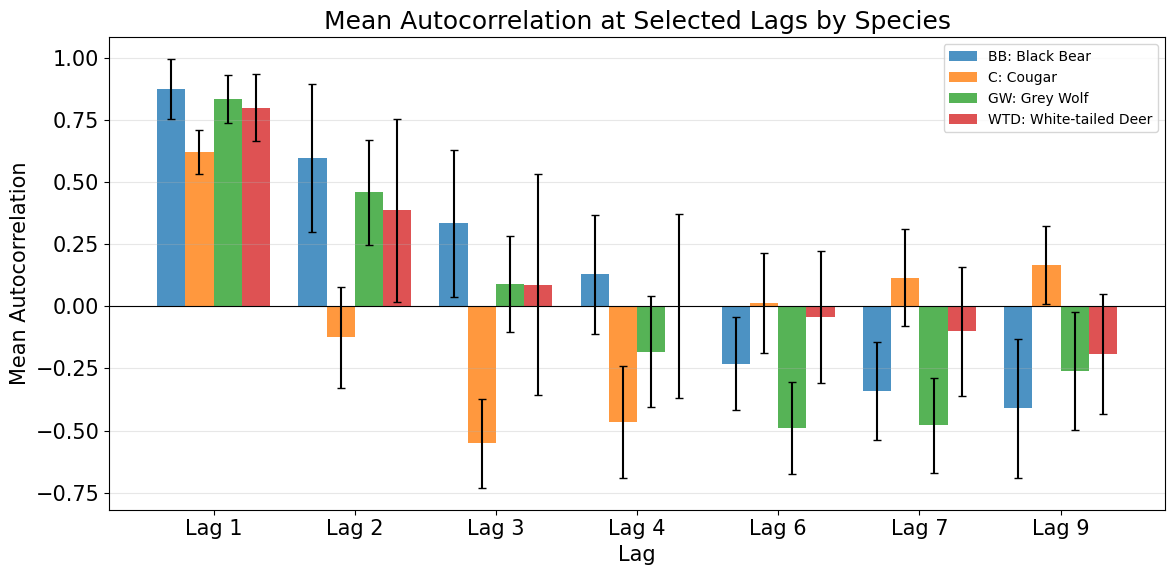

In [12]:
# Plot 3: Mean autocorrelation at selected lags by species (bar chart)
fig, ax = plt.subplots(figsize=(12, 6))

x_positions = np.arange(len(HIGHLIGHT_LAGS))
width = 0.2
offset_map = {'BB': -1.5, 'C': -0.5, 'GW': 0.5, 'WTD': 1.5}

for code, name in CLASS_NAMES.items():
    if code not in autocorr_data:
        continue
    
    mean_acf = autocorr_data[code]['mean']
    std_acf = autocorr_data[code]['std']
    
    values = [mean_acf[lag] if lag < len(mean_acf) else 0 for lag in HIGHLIGHT_LAGS]
    errors = [std_acf[lag] if lag < len(std_acf) else 0 for lag in HIGHLIGHT_LAGS]
    
    offset = offset_map[code] * width
    ax.bar(x_positions + offset, values, width, 
           label=f"{code}: {name}",
           color=CLASS_COLORS[code],
           alpha=0.8,
           yerr=errors,
           capsize=3)

ax.set_xlabel("Lag")
ax.set_ylabel("Mean Autocorrelation")
ax.set_title("Mean Autocorrelation at Selected Lags by Species")
ax.set_xticks(x_positions)
ax.set_xticklabels([f"Lag {lag}" for lag in HIGHLIGHT_LAGS])
ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.rcParams.update({'font.size': 15})
pdf_path = OUTPUT_DIR / 'mean_autocorr_selected_lags.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")
plt.show()